# (26) Kyoto32 + T16:  [512, 4, 4], 6

**Motivation**: host = ```chewie```, device = ```cuda:1``` <br>

This means:

- ```K = 512```
- ```M = 4```
- ```S = 6```

And:

- ```T_train = 16```

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('Kyoto32-wht', model_type, 'ngd|lin')

t_train = 16

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 4/8 * t_train

cfg_vae['latent_channels'] = 512
cfg_vae['latent_pixels'] = 4
cfg_vae['latent_stride'] = 6

cfg_tr['batch_size'] = 100
cfg_tr['epochs'] = 1700

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

183600

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  101.4 K   |
|     ———     |    ———     |
|    layer    |  101.4 K   |
+-------------+------------+

poisson_Kyoto32-wht_t-16_b-8_k-512_m-4_s-6_<ngd|lin>
b100-ep1700-lr(0.001)_temp(0.05)_gr(200)_(2025_06_26,22:30)

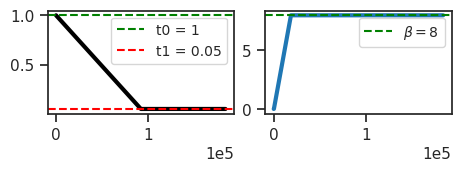

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}\n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(512, 4, 4), input_sz=(1, 32, 32), temp=1)
ConvDictionary(in_channels=512, out_channels=1, kernel_size=14, stride=6)

In [8]:
tr.model.layer.dec.weight.shape

torch.Size([512, 1, 14, 14])

In [9]:
tr.model.layer.u_init[0].shape, tr.model.layer.log_bias.shape

(torch.Size([1, 512, 1, 1]), torch.Size([1, 512, 1, 1]))

In [10]:
tr.train()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 1700, avg loss: 441.360: 100%|███| 1700/1700 [10:09:02<00:00, 21.50s/it]


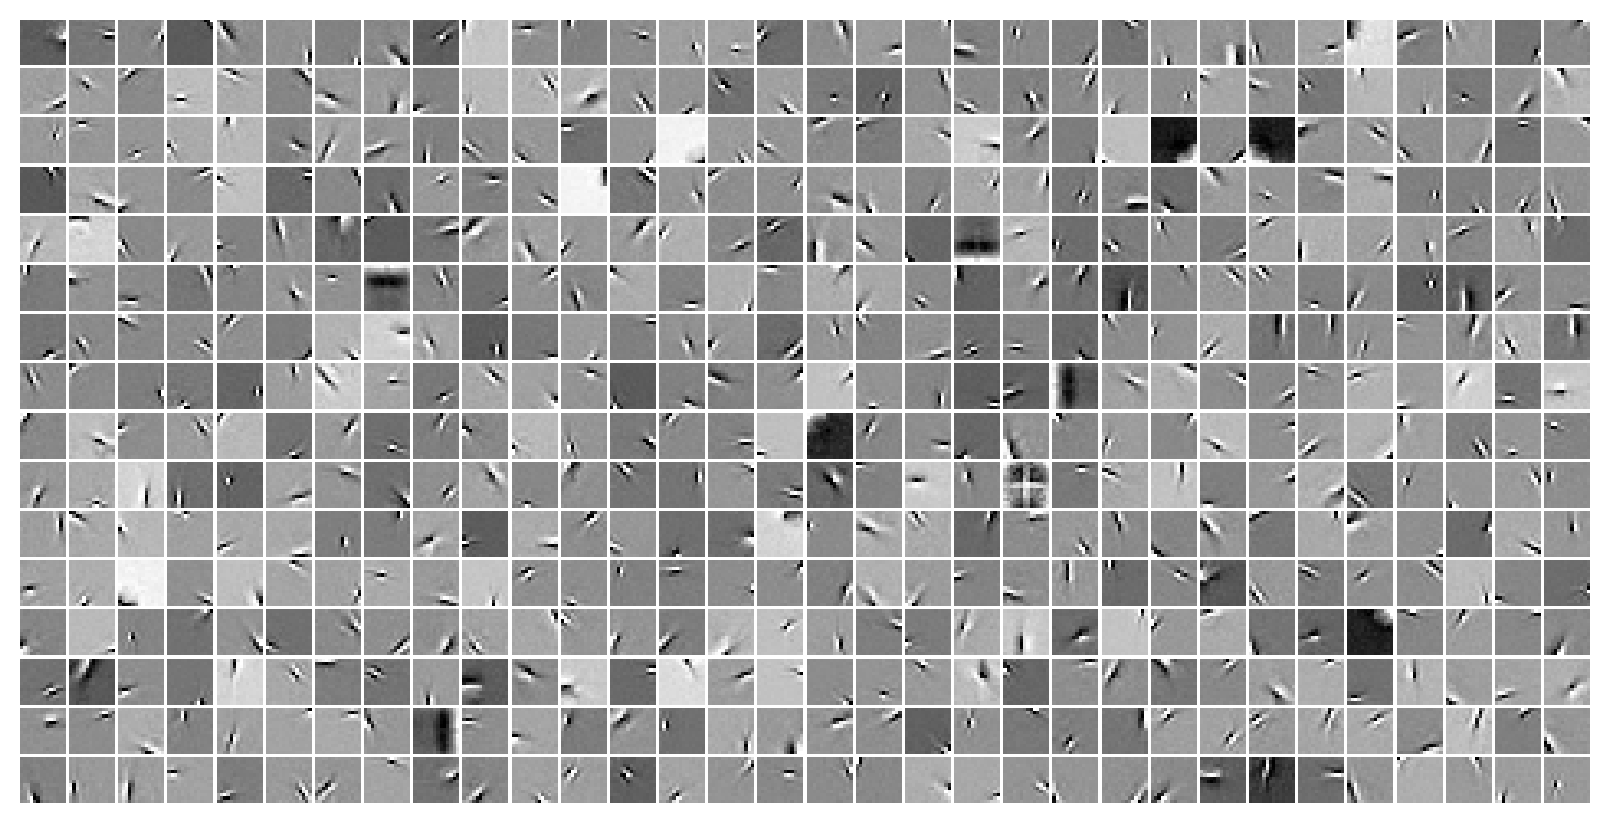

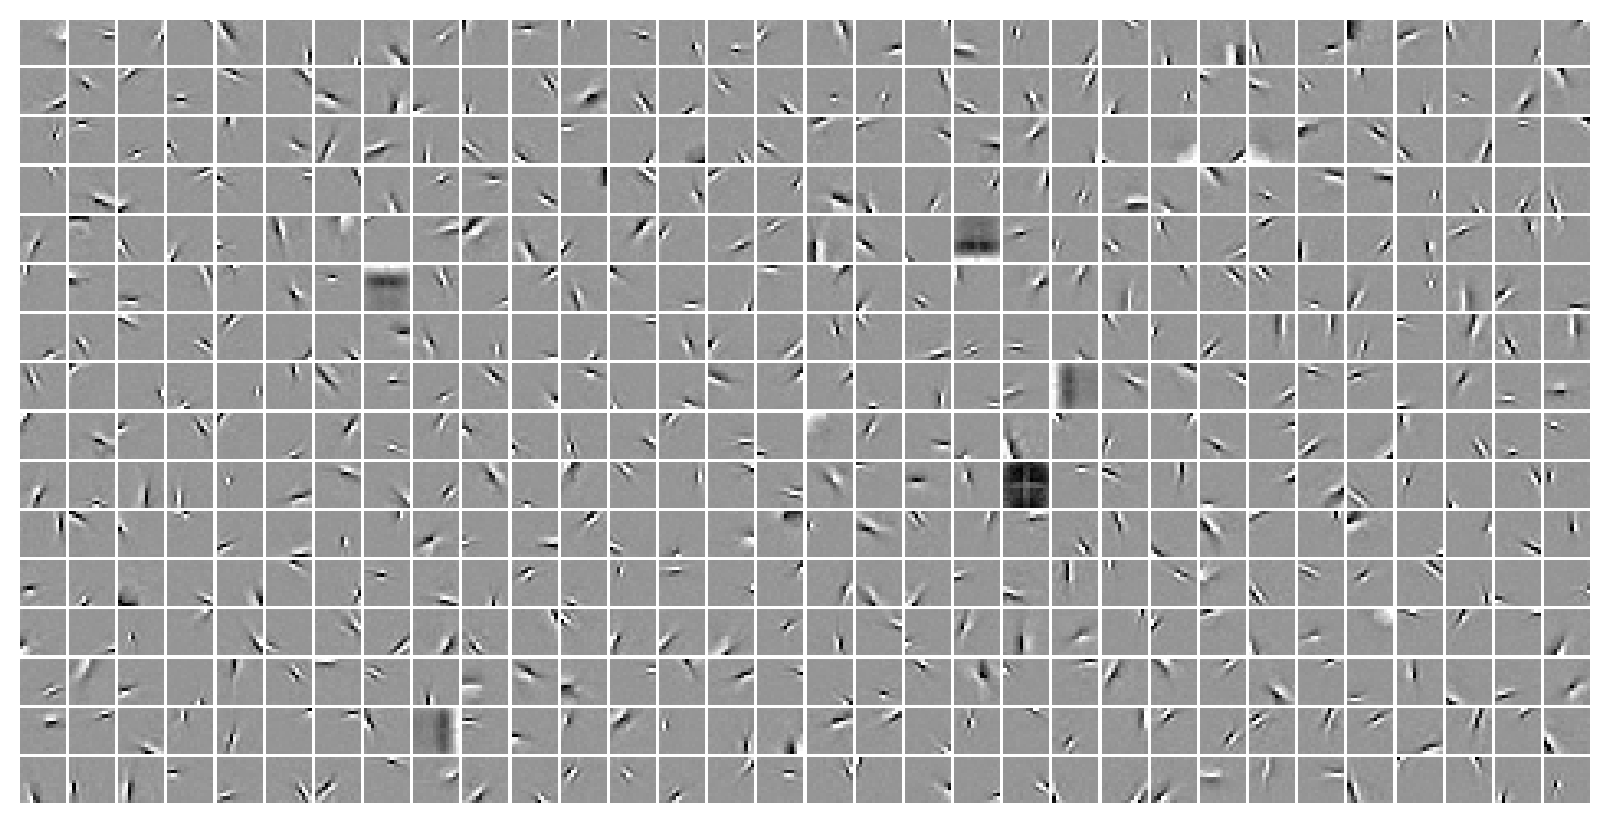

In [12]:
tr.model.show();
tr.model.show(method='abs-max');

100%|███████████████████████████████████| 5/5 [00:13<00:00,  2.69s/it]


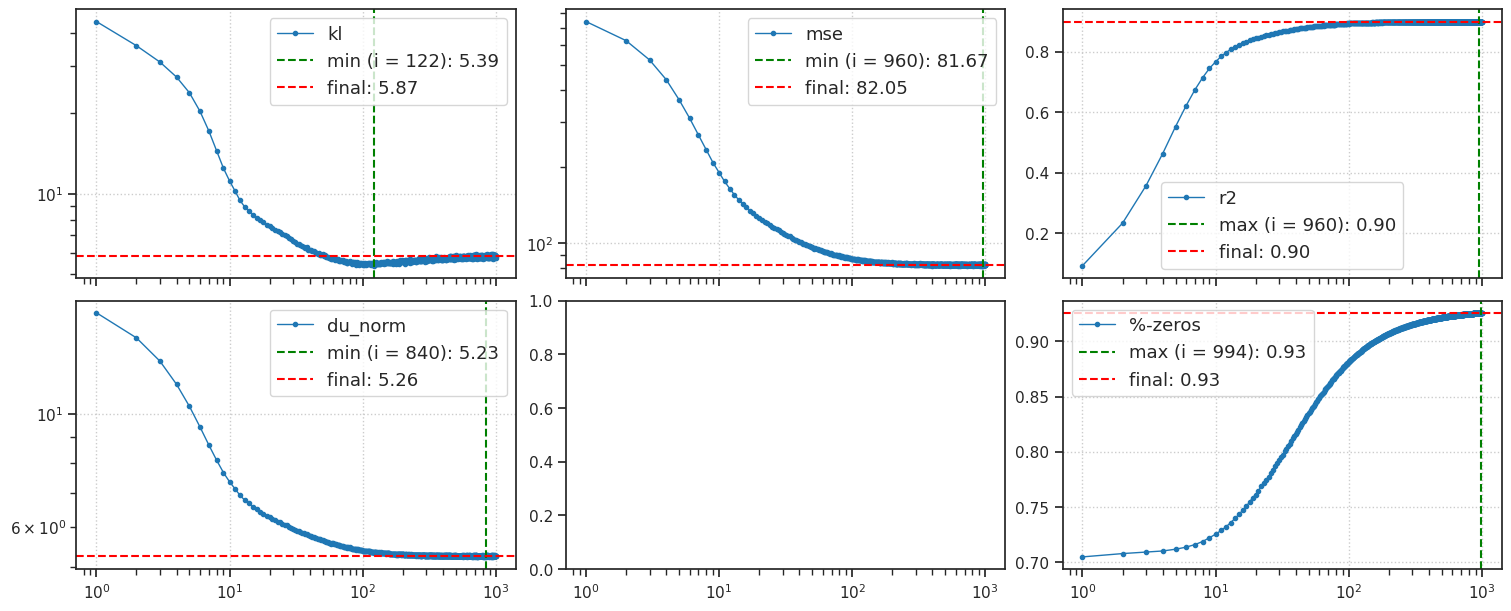

CPU times: user 27.9 s, sys: 4.06 s, total: 32 s
Wall time: 32 s


In [14]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis(data='vld', **kws)
_ = plot_convergence(results, color='C0')

100%|███████████████████████████████████| 5/5 [00:22<00:00,  4.58s/it]


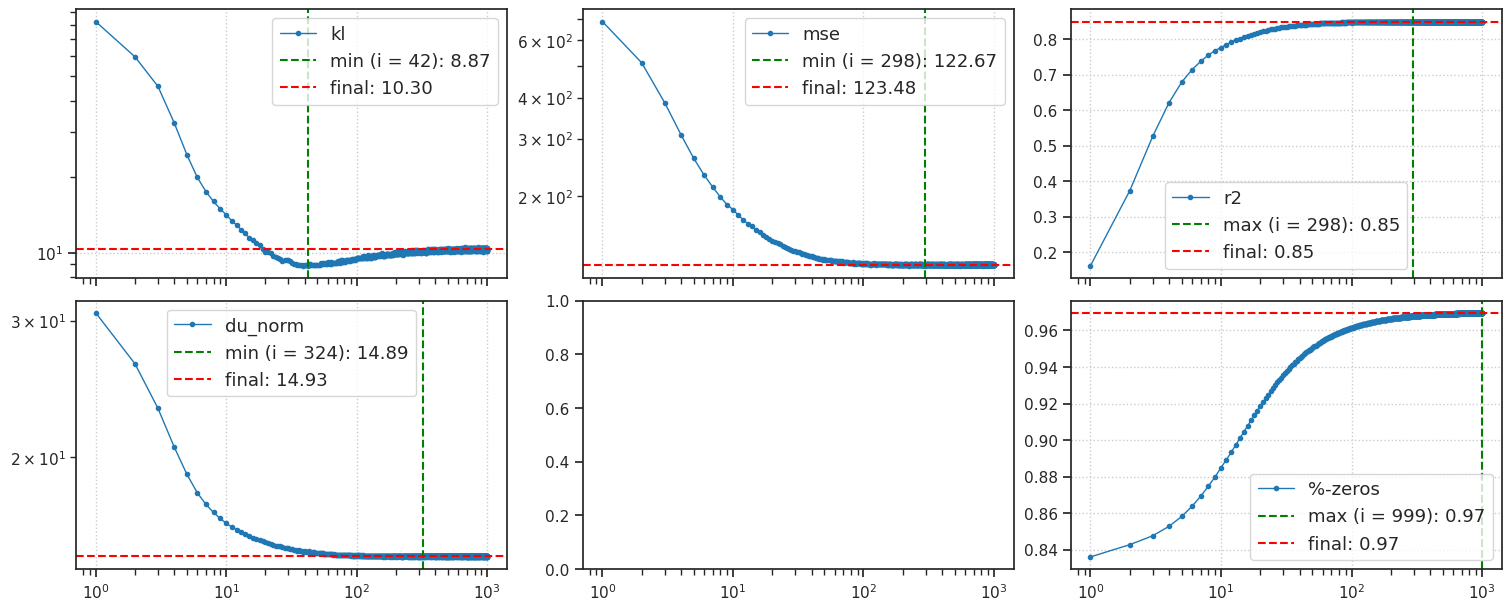

CPU times: user 46.7 s, sys: 11.8 s, total: 58.5 s
Wall time: 58.6 s


In [14]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)
bias.shape

(256,)

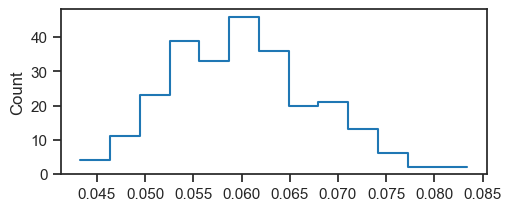

In [17]:
fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

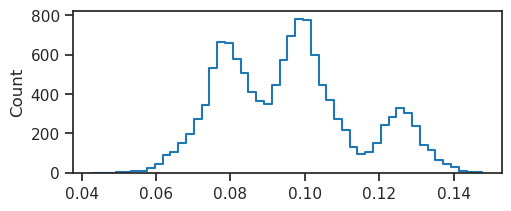

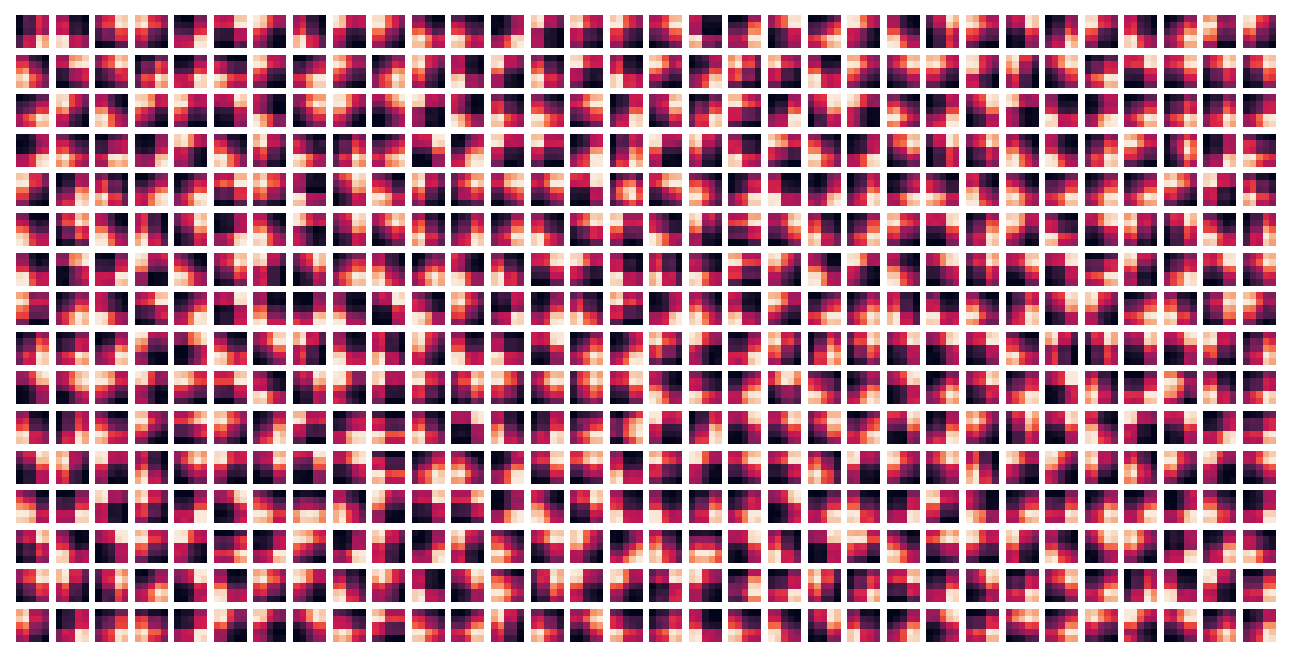

In [50]:
plot_weights(bias, nrows=16, cmap='rocket');

In [18]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u0.shape

(256,)

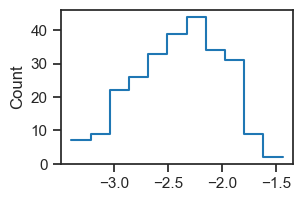

In [19]:
histplot(u0.ravel())
plt.show()

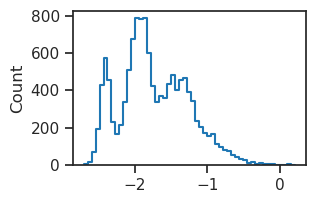

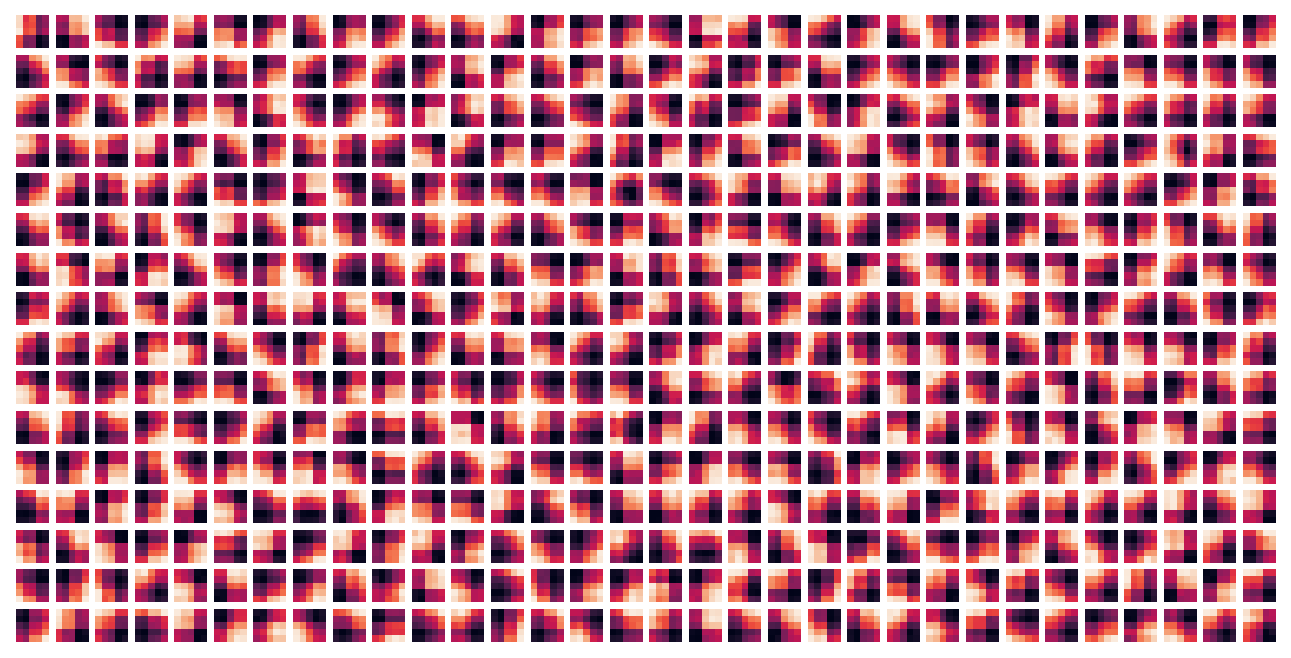

In [53]:
plot_weights(u0, nrows=16, cmap='rocket');

In [20]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.8146489227159844, pvalue=4.890027834736615e-62)

PearsonRResult(statistic=-0.9887892205208767, pvalue=0.0)

In [12]:
# a = 'poisson_vH16-wht_t-8_b-4_k-128_m-8_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:M=8_(2025_06_21,23:44)'
# tr, meta = load_model(pjoin(a, b), device)
# meta['checkpoint']